# CO2 Emissions and the Kusnetz curve

In this exercise, you must use data from the WorldBank to check whether CO2 Emissions can be explained by income per capita.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Work

### Importing CO2 Data

__Import the data from file `/files/tutorials/session_9/data/API_EN.ATM.CO2E.PC_DS2_en_csv_v2_5177406.csv` as a dataframe `df_wide`. (This table was downloaded from the worldbank website)__

Hints: check the documentation from `pandas.read_csv()` to avoid the import error. You can check the first few lines of the file by typing in a cell:
`!/files/tutorials/session_9_wrap_up/data/API_EN.ATM.CO2E.PC_DS2_en_csv_v2_5177406.csv`

Hint2: Check that all columns are well defined.

In [5]:
path_data='data/API_EN.ATM.CO2E.PC_DS2_en_csv_v2_5177406.csv'

df_wide = pd.read_csv(path_data, skiprows=4)

In [6]:
df_wide

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Unnamed: 66
0,Aruba,ABW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.995665,1.006938,0.956704,0.938565,0.928508,0.908094,0.903764,NaN,NaN,NaN
2,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.189910,0.149162,0.176278,0.153019,0.134106,0.165455,0.160976,NaN,NaN,NaN
3,Africa Western and Central,AFW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.499219,0.506918,0.485478,0.490807,0.474882,0.478305,0.485884,NaN,NaN,NaN
4,Angola,AGO,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,1.031093,1.092216,1.125224,1.020760,0.802751,0.766143,0.779203,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,1.031352,0.988351,0.475163,0.370636,0.333285,0.315682,0.351859,NaN,NaN,NaN
263,South Africa,ZAF,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,8.110093,8.184427,7.602659,7.534968,7.691396,7.575040,7.568640,NaN,NaN,NaN
264,Zambia,ZMB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.278307,0.298009,0.305264,0.317276,0.393686,0.433396,0.369958,NaN,NaN,NaN


<font color='blue'>__Question 1: *Describe briefly the data.*__ </font>


_The data contains information on the level of carbon dioxide (CO2) emissions per capita (in metric tons) for different countries and regions over the years 1960 to 2019. The data is sourced from the World Bank's World Development Indicators and is reported annually._

_The dataset contains 264 rows (corresponding to different countries and regions) and 61 columns (corresponding to the years 1960 to 2019 and additional columns with country and region information). The data is in a wide format, with each row representing a country/region and each column representing a year._

_The data is useful for analyzing trends in CO2 emissions over time and comparing emissions across countries and regions. It can also be used for exploring the relationship between CO2 emissions and various economic and environmental factors._

In [8]:
df_wide.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Unnamed: 66
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.288766,4.194242,4.141210,4.140690,4.148584,4.128191,4.086604,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.002821,4.862196,4.731198,4.653372,4.585664,4.489473,4.474616,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.024987,0.027090,0.037289,0.029718,0.033815,0.035826,0.035704,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.720891,0.785259,0.771880,0.769068,0.802179,0.797275,0.790333,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.726281,2.888558,2.827949,2.760181,2.699348,2.979403,2.981762,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.264131,6.028664,5.792812,5.828931,6.021844,5.950694,5.890683,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,37.420762,36.875726,35.111798,33.493040,32.281678,31.235406,32.761775,NaN,NaN,NaN


In [19]:
# get rid of last column
df_wide = df_wide.iloc[:,:-1]
df_wide

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.970188,0.983547,0.995665,1.006938,0.956704,0.938565,0.928508,0.908094,0.903764,NaN
2,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.305308,0.265210,0.189910,0.149162,0.176278,0.153019,0.134106,0.165455,0.160976,NaN
3,Africa Western and Central,AFW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.468718,0.472242,0.499219,0.506918,0.485478,0.490807,0.474882,0.478305,0.485884,NaN
4,Angola,AGO,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.983960,0.947663,1.031093,1.092216,1.125224,1.020760,0.802751,0.766143,0.779203,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.900862,0.801193,1.031352,0.988351,0.475163,0.370636,0.333285,0.315682,0.351859,NaN
263,South Africa,ZAF,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,7.803853,8.030478,8.110093,8.184427,7.602659,7.534968,7.691396,7.575040,7.568640,NaN
264,Zambia,ZMB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,0.213798,0.273319,0.278307,0.298009,0.305264,0.317276,0.393686,0.433396,0.369958,NaN


The data contains yearly carbon emissions *per capita*, for all countries, starting in 1960 until 2021 (with some missing data)

### Cleaning up CO2 Data

<font color='blue'>__Question 2: convert the data into the long format using the function `pandas.melt()`. The columns of the new table `df_long` should be: `["Country Name","Country Code","Indicator Name","Indicator Code", "Date", "Emissions"]`__ </font>

In [9]:
df_long = pd.melt(df_wide,
        id_vars=["Country Name","Country Code","Indicator Name","Indicator Code"],
        var_name="Date",
        value_name="Emissions"
)

In [12]:
df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Date,Emissions
7981,Africa Eastern and Southern,AFE,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990,0.982136
7982,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990,0.222538
7983,Africa Western and Central,AFW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990,0.473669
7984,Angola,AGO,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990,0.554586
7985,Albania,ALB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990,1.819542


<font color='blue'>__Question 3: Eliminate all rows for which no emission data is available__</font>

In [13]:
df_long = df_long.dropna()

<font color='blue'>__Question 4: Convert the `Date` column into a date format.__</font>

*Hint: look for pandas.to_datetime() (This is not absolutely mandatory but makes graphs nicer)*

In [14]:
df_long['Date']

7981     1990
7982     1990
7983     1990
7984     1990
7985     1990
         ... 
15954    2019
15956    2019
15957    2019
15958    2019
15959    2019
Name: Date, Length: 7147, dtype: object

In [15]:
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long['Date']

7981    1990-01-01
7982    1990-01-01
7983    1990-01-01
7984    1990-01-01
7985    1990-01-01
           ...    
15954   2019-01-01
15956   2019-01-01
15957   2019-01-01
15958   2019-01-01
15959   2019-01-01
Name: Date, Length: 7147, dtype: datetime64[ns]

### Importing World Bank Data

From the world bank website, we download data for historical __real gdp__ and __population__. 


__Checkout the [wbdata](https://github.com/OliverSherouse/wbdata) library. Import time series for GDP and Total Population for all countries.__

In [16]:
import wbdata

In [17]:
indicators = {
    "NY.GDP.MKTP.CD": "GDP",
    "SP.POP.TOTL": "Total Population"
}
df_wb = wbdata.get_dataframe(indicators).reset_index()
df_wb

,country,date,GDP,Total Population
0,Africa Eastern and Southern,2023,NaN,NaN
1,Africa Eastern and Southern,2022,1.185138e+12,720859132.0
2,Africa Eastern and Southern,2021,1.086531e+12,702977106.0
3,Africa Eastern and Southern,2020,9.288802e+11,685112979.0
4,Africa Eastern and Southern,2019,1.006191e+12,667242986.0
...,...,...,...,...
17019,Zimbabwe,1964,1.217138e+09,4310332.0
17020,Zimbabwe,1963,1.159512e+09,4177931.0
17021,Zimbabwe,1962,1.117602e+09,4049778.0
17022,Zimbabwe,1961,1.096647e+09,3925952.0


<font color='blue'>__Question 5: Change the format of column `date` to datetime.__</font>

In [20]:
df_wb['date'] =  pd.to_datetime(df_wb['date'])
df_wb.head()

,country,date,GDP,Total Population
0,Africa Eastern and Southern,2023-01-01,NaN,NaN
1,Africa Eastern and Southern,2022-01-01,1.185138e+12,720859132.0
2,Africa Eastern and Southern,2021-01-01,1.086531e+12,702977106.0
3,Africa Eastern and Southern,2020-01-01,9.288802e+11,685112979.0
4,Africa Eastern and Southern,2019-01-01,1.006191e+12,667242986.0


<font color='blue'>__Question 6: Change columns of `df_wb` to ["Country Name", "Date", "GDP", "Population"].__</font>

In [21]:
df_wb.columns =  ["Country Name", "Date", "GDP", "Population"]

In [22]:
df_wb.columns

Index(['Country Name', 'Date', 'GDP', 'Population'], dtype='object')

### Merging CO2 and World Bank Data

<font color='blue'>__Question 7: Merge the datafames df_wb and df_long into a single dataframe `df_kuznetz`.__

We perform the same steps as in the first part for both series then `merge` the resulting long databases "on" the `Country Code` and `Date` columns.

You should obtain one single database `data` containing the columns `["Country Name","Country Code","Indicator Name","Indicator Code","Date", "Emissions", "GDP", "Population"]`

In [23]:
df_kuznets = df_long.merge(df_wb, on=["Country Name","Date"])

## 2. Data exploration 

### 2.1 Graphical representation

<font color='blue'>__Question 8: Compute total emissions for each country.__</font>

In [24]:
# Let' s compute total emissions (for each year):

df_kuznets["TEmissions"] = df_kuznets["Emissions"]*df_kuznets["Population"]

In [25]:
df_kuznets.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Date,Emissions,GDP,Population,TEmissions
0,Africa Eastern and Southern,AFE,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990-01-01,0.982136,2.546735e+11,309890664.0,3.043549e+08
1,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990-01-01,0.222538,NaN,10694796.0,2.380000e+06
2,Africa Western and Central,AFW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990-01-01,0.473669,1.218036e+11,206739024.0,9.792580e+07
3,Angola,AGO,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990-01-01,0.554586,1.123628e+10,11828638.0,6.560000e+06
4,Albania,ALB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1990-01-01,1.819542,2.028554e+09,3286542.0,5.980000e+06


In [26]:
# solution 1: loop over each country
for country in df_kuznets['Country Name'].unique():
    df_c = df_kuznets[df_kuznets['Country Name']==country]
    te = df_c["TEmissions"].sum()
    print(f"Total emissions for '{country}': {te}")

Total emissions for 'Africa Eastern and Southern': 13404472170.208675
Total emissions for 'Afghanistan': 95460000.50544737
Total emissions for 'Africa Western and Central': 4638752133.020737
Total emissions for 'Angola': 553169997.2534183
Total emissions for 'Albania': 112550000.08583067
Total emissions for 'Andorra': 14629999.967813494
Total emissions for 'Arab World': 37093235321.97194
Total emissions for 'United Arab Emirates': 3725519996.948244
Total emissions for 'Argentina': 4374320037.231444
Total emissions for 'Armenia': 170760000.12397763
Total emissions for 'Antigua and Barbuda': 12969999.953508377
Total emissions for 'Australia': 10421789732.640446
Total emissions for 'Austria': 1971999996.7956543
Total emissions for 'Azerbaijan': 979830002.1362305
Total emissions for 'Burundi': 8450000.043511389
Total emissions for 'Belgium': 3206549994.5068383
Total emissions for 'Benin': 93380000.51498412
Total emissions for 'Burkina Faso': 53590000.25987626
Total emissions for 'Banglades

In [28]:
# solution 2: use groupby
total_emissions_per_country = df_kuznets.groupby('Country Name')['TEmissions'].sum()
total_emissions_per_country

Country Name
Afghanistan                    9.546000e+07
Africa Eastern and Southern    1.340447e+10
Africa Western and Central     4.638752e+09
Albania                        1.125500e+08
Algeria                        3.119610e+09
                                   ...     
Venezuela, RB                  4.126760e+09
World                          8.128743e+11
Yemen, Rep.                    4.841400e+08
Zambia                         9.441000e+07
Zimbabwe                       3.812100e+08
Name: TEmissions, Length: 238, dtype: float64

<font color='blue'>__Question 9: Plot the evolution over time of total recorded carbon emissions (ommiting dates where no information is available).__</font>

Hint: use `groupby()`

In [29]:
total_emissions_per_year = df_kuznets.groupby('Date')['TEmissions'].sum()
total_emissions_per_year.head()

Date
1990-01-01    1.774377e+11
1991-01-01    1.788978e+11
1992-01-01    1.788542e+11
1993-01-01    1.798608e+11
1994-01-01    1.801915e+11
Name: TEmissions, dtype: float64

Text(0.5, 1.0, 'Total Carbon Emissions (world)')

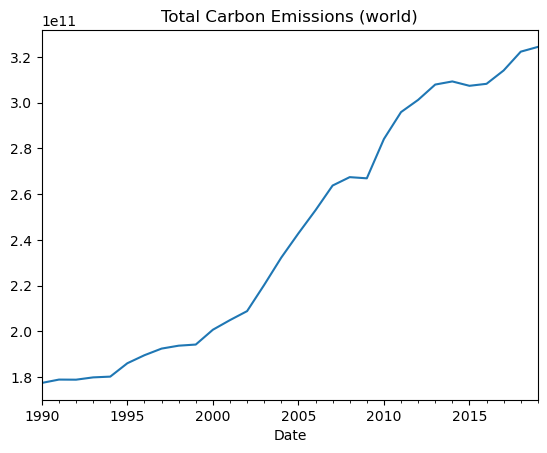

In [33]:
from matplotlib import pyplot as plt
total_emissions_per_year.plot()
plt.title("Total Carbon Emissions (world)")

Text(0.5, 1.0, 'Cumulated Carbon Emissions (world)')

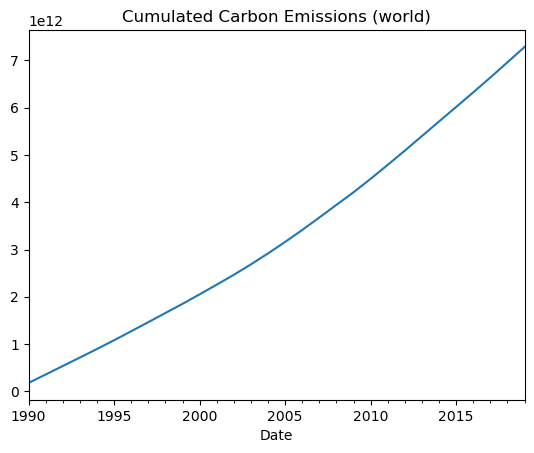

In [34]:
# to get the cumulated emissions
total_emissions_per_year.cumsum().plot()
plt.title("Cumulated Carbon Emissions (world)")

<font color='blue'>__(optional) Question 10 : Propose some plots to visualize the contribution of the main contributors to yearly carbon emissions and to cumulative carbon emissions. You can get inspiration from [ourworldindata](https://ourworldindata.org/co2-emissions).__</font>

_We could use a pie Chart of Global Emissions by Top 10 Emitters. This plot would show us the percentage of global carbon emissions of the top 10 emitters, with each country's contribution shown as a colored segment of a pie chart in order to provide the relative contributions of each country to global emissions._
_We could also use an area chart of cumulative emissions by top emitters: This plot shows the cumulative carbon emissions over time for the top emitters, with each country's contribution shown as a colored area of a stacked area chart. This plot allows for easy comparison of the contributions of different countries to cumulative emissions._

### 2.2 Geo-analysis

In [40]:
from plotly import express as px

#### 2.2.1. Total emissions per country

<font color='blue'>__Question 11 : Change the following piece of code so that it represents, total emission per country (over time).__</font>


In [41]:
# we need to replace emissions per capita by "total emissions" (`TEmissions`)

In [42]:
emissions_per_country=df_kuznets[df_kuznets['TEmissions'].notnull()].groupby(["Country Name","Country Code"])['TEmissions'].sum().reset_index()
emissions_per_country

,Country Name,Country Code,TEmissions
0,Afghanistan,AFG,9.546000e+07
1,Africa Eastern and Southern,AFE,1.340447e+10
2,Africa Western and Central,AFW,4.638752e+09
3,Albania,ALB,1.125500e+08
4,Algeria,DZA,3.119610e+09
...,...,...,...
233,"Venezuela, RB",VEN,4.126760e+09
234,World,WLD,8.128743e+11
235,"Yemen, Rep.",YEM,4.841400e+08
236,Zambia,ZMB,9.441000e+07


In [56]:
fig = px.choropleth(emissions_per_country, 
                    locations="Country Code",
                    color="TEmissions", # lifeExp is a column of gapminder
                    hover_name="Country Name", # column to add to hover information
                    color_continuous_scale='YlOrRd',
                    title="Total Emissions per Country (1990-2019)")
fig.update_layout(width=900, height=500)
fig.show()

#### 2.2.3 Emission evolution per country

The following plot represents the evolution of CO2 emission per capita for various countries.

In [46]:
#Difference between the first and the last date, per country
evol_per_country = df_long.groupby(['Country Name',"Country Code"])['Emissions'].agg(['first', 'last']).reset_index()

# CO2 emission evolution
evol_per_country['Evolution'] = evol_per_country['last'] - evol_per_country['first']

In [50]:
df_long['Date'].min(),df_long['Date'].max(),

(Timestamp('1990-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00'))

In [52]:
fig = px.choropleth(evol_per_country, locations="Country Code",
                    color="Evolution", # lifeExp is a column of gapminder
                    hover_name="Country Name", # column to add to hover information
                    color_continuous_scale='YlOrRd',
                    title="Increase of Emissions per Capita (1990-2019)"
                   )
fig.update_layout(width=900, height=500)
fig.show()

<font color='blue'>__Question 12 : Adapt the preceding piece of code so that it represents, the evolution of total emission per country.__</font>

In [53]:
#Difference between the first and the last date, per country
evol_per_country_total = df_kuznets.groupby(['Country Name',"Country Code"])['TEmissions'].agg(['first', 'last']).reset_index()

# CO2 emission evolution
evol_per_country_total['Evolution'] = evol_per_country_total['last'] - evol_per_country_total['first']

In [55]:
fig = px.choropleth(evol_per_country_total, locations="Country Code",
                    color="Evolution", # lifeExp is a column of gapminder
                    hover_name="Country Name", # column to add to hover information
                    color_continuous_scale='YlOrRd',
                    title="Increase in total Emissions (1990-2019)"
)

fig.update_layout(width=900, height=500)
fig.show()

## 3. The Kusnetz curve

We are now interested in the relation between carbon emission and economic development. To this purpose, we would like to run a *simple* regression

$$\frac{ \text{emissions}_{i t} }{ \text{population}_{i t} } = \alpha + \beta*\frac{ \text{gdp}_{i t}}{\text{population}_{i t}} + \text{other factors}_{i t}$$

where $i$ is the country index and $t$ the time index. In a first step we will simply assume that the total effect of all `other factors` is normally distributed.

We would then like to consider variants of this regression in order to test the environment Kuznets curve hypothesis.

<font color='blue'>__Question 10: Briefly summarize the environmental Kuznets curve hypothesis__</font>

(hint: perform a small websearch. Try to identify your sources)

_The Environmental Kuznets Curve hypothesis postulates an inverted-U-shaped relationship between different pollutants and per capita income, i.e., environmental pressure increases up to a certain level as income goes up; after that, it decreases. The environmental pollution increases at the beginning of economic growth. However, when it passes a certain level of income, the economic growth allows environmental remediation._ from Environmental Kuznets Curve: The Evidence from BSEC Countries* - / EGE ACADEMIC REVIEW and "Environmental Kuznets Curve Hypothesis: A Survey" from Ecological Economics

<font color='blue'>__Question 11: Regress per capita emissions on gdp per capita and comment.__</font>

In [59]:
from statsmodels.formula import api as smf
df_kuznets['GDP_per_capita']=df_kuznets['GDP']/1000/df_kuznets['Population']
#on divise le PIB par mille car c'est en million et la population est en milliers

In [ ]:
model=smf.ols(" Emissions ~ GDP_per_capita ", df_kuznetz)
res=model.fit()
res.summary()

_The estimated regresssion is `emissions per capita = 2,45+ 0,1852 gdp per capita`. Both the intercept and the coefficient are significant, indicating that higher GDP per capita is associated with higher per capita emissions, holding other factors constant. The R-squared of the model is relatively low at 0.334, suggesting that other factors not included in the model may also be important in explaining per capita emissions._

<font color='blue'>__Question 12: Split the sample into the three quantiles, based on gdp/capita in the last period. Run the same regression in all three subsamples. Comment.__</font>


In [62]:
df_kuznets['Quantile']= pd.qcut(df_kuznets['GDP_per_capita'],q = 3, labels=['low', 'medium', 'high'])
model_low=smf.ols(" Emissions ~ GDP_per_capita ", df_kuznets[df_kuznets['Quantile'] == "low"])
res_low=model_low.fit()
res_low.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Emissions   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     200.1
Date:                Sun, 07 Apr 2024   Prob (F-statistic):           1.27e-43
Time:                        23:03:16   Log-Likelihood:                -4015.4
No. Observations:                2303   AIC:                             8035.
Df Residuals:                    2301   BIC:                             8046.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0768      0.064      1.205      0.228      -0.048       0.202
GDP_per_capita     1.1274      0.080     14.145      0.000       0.971       1.284
==============================================================================
Omnibus:                     1826.266   Durbin-Watson:                   1.594
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34369.056
Skew:                           3.736   Prob(JB):                         0.00
Kurtosis:                      20.388   Cond. No.                         4.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
model_medium=smf.ols(" Emissions ~ GDP_per_capita ", df_kuznets[df_kuznets['Quantile'] == "medium"])
res_medium=model_medium.fit()
res_medium.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Emissions   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     236.0
Date:                Sun, 07 Apr 2024   Prob (F-statistic):           8.79e-51
Time:                        23:03:47   Log-Likelihood:                -5186.0
No. Observations:                2299   AIC:                         1.038e+04
Df Residuals:                    2297   BIC:                         1.039e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1684      0.124      9.443      0.000       0.926       1.411
GDP_per_capita     0.5272      0.034     15.364      0.000       0.460       0.594
==============================================================================
Omnibus:                      922.711   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3721.972
Skew:                           1.961   Prob(JB):                         0.00
Kurtosis:                       7.844   Cond. No.                         9.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
model_high=smf.ols(" Emissions ~ GDP_per_capita ", df_kuznets[df_kuznets['Quantile'] == "high"])
res_high=model_high.fit()
res_high.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Emissions   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     192.4
Date:                Sun, 07 Apr 2024   Prob (F-statistic):           4.44e-42
Time:                        23:04:03   Log-Likelihood:                -7386.5
No. Observations:                2302   AIC:                         1.478e+04
Df Residuals:                    2300   BIC:                         1.479e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.8578      0.194     35.438      0.000       6.478       7.237
GDP_per_capita     0.0824      0.006     13.872      0.000       0.071       0.094
==============================================================================
Omnibus:                     1125.974   Durbin-Watson:                   1.959
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7949.756
Skew:                           2.210   Prob(JB):                         0.00
Kurtosis:                      10.958   Cond. No.                         50.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

_These three linear regressions show us that the higher the GDP per capita of countries, the higher the R-squared. This means that the model is more predictive for countries with a "high" GDP, the higher their GDP per capita, the higher their per capita emissions. This partly confirms the Kuznetz curve hypothesis_


<font color='blue'>__Question 13. Instead of splitting the sample, run a nonlinear regression:__</font>

$$\frac{ \text{emissions}_{i t} }{ \text{population}_{i t} } = \alpha + \beta_1*\frac{ \text{gdp}_{i t}}{\text{population}_{i t}} + \beta_2*\left( \frac{ \text{gdp}_{i t}}{\text{population}_{i t}} \right)^2 + \text{other factors}_{i t}$$

Justify why $\beta_2<0$ can be interpreted as a proof of the environmental Kuznets hypothesis. Comment.



In [67]:
import numpy as np
nonlinear_regression=smf.ols('Emissions ~ GDP_per_capita + np.power(GDP_per_capita, 2)',df_kuznets)
res_nl=nonlinear_regression.fit()
res_nl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Emissions   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     2997.
Date:                Sun, 07 Apr 2024   Prob (F-statistic):               0.00
Time:                        23:04:36   Log-Likelihood:                -19043.
No. Observations:                6904   AIC:                         3.809e+04
Df Residuals:                    6901   BIC:                         3.811e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.5058      0.058     25.901      0.000       1.392       1.620
GDP_per_capita                  0.3718      0.005     69.641      0.000       0.361       0.382
np.power(GDP_per_capita, 2)    -0.0024   5.77e-05    -41.234      0.000      -0.002      -0.002
==============================================================================
Omnibus:                     4635.223   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           102447.422
Skew:                           2.899   Prob(JB):                         0.00
Kurtosis:                      20.959   Cond. No.                     1.96e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.96e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

_The coefficient on the quadratic term, 𝛽2, is negative, standing at -0,0024, which support the hypothesis that the relationship between emissions and GDP per capita is U-shaped and consistent with the EKH._

__(Bonus) Suggest a way to improve the regression.__

_this result alone does not provide conclusive proof of the EKH, as the coefficient is not statistically significant and as there may be other factors that influence the relationship between emissions and GDP per capita_